# pyLDAvis
# Полезные ссылки:</br>
1.How to Create an LDA Topic Model in Python with Gensim (Topic Modeling for DH 03.03) - https://www.youtube.com/watch?v=TKjjlp5_r7o&list=PL2VXyKi-KpYttggRATQVmgFcQst3z6OlX&index=
https://github.com/wjbmattingly/topic_modeling_textbook/blob/main/03_03_lda_model_demo.ipynb
2. pyLDAvis - https://pypi.org/project/pyLDAvis/
3. gensim lda - https://radimrehurek.com/gensim/models/ldamodel.html
4. Статья - https://nlp.stanford.edu/events/illvi2014/papers/sievert-illvi2014.pdf
5. Статья Topic Modeling with LSA, pLSA, LDA, NMF, BERTopic, Top2Vec: a Comparison - https://readmedium.com/topic-modeling-with-lsa-plsa-lda-nmf-bertopic-top2vec-a-comparison-5e6ce4b1e4a5


# 0. Импорты
## Используем отдельное виртуальное окружение .venv_LDA из-за необходимости определенной версии numpy для gensim. Сначало устанавливаем gensin. а затем всё остальное

In [161]:
from collections import defaultdict

import pandas as pd
import nltk
from nltk.corpus import stopwords
import re
import string
from tqdm import tqdm
import numpy as np
from wordcloud import WordCloud
#Gensim
import gensim
import gensim.corpora as corpora

#vis
import pyLDAvis
import pyLDAvis.gensim
import matplotlib.pyplot as plt

# 1. Загрузка датасета

In [162]:
df = pd.read_json("data/data.txt", lines=True)
df

,text,tags,schema_name,table_name
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876


# 2. Очистка данных

In [163]:
# Загрузка стоп-слов (один раз при старте)
nltk.download('stopwords')
stop_words = set(stopwords.words('russian')) # Загрузка стоп-слов (один раз при старте)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [164]:
# Функция для очистки текста
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Удаление URL
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE)
    # Удаление цифр и специальных символов
    text = re.sub(r'\d+', ' ', text)
    # оставляем только буквы
    text = re.sub(r'[^a-zA-Zа-яА-ЯёЁ]', ' ', text)
    # Удаление пунктуации
    # text = text.translate(str.maketrans('', '', string.punctuation))
    translator = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    text = text.translate(translator)
    # Приведение к нижнему регистру (не всегда обязательно, возможно ухудшит качество)
    text = text.lower()
    # Удаление стоп-слов (не всегда обязательно, возможно ухудшит качество)
    stop_words = set(stopwords.words('russian'))
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(words)

In [165]:
# Функция для получения имени сервиса. Именем сервиса является номер на 2-ой позиции в списке тегов
def get_service_name(list_of_tags):
    # если недостаточное кол-во тегов -> нет сервиса -> возвращаем пустую строку
    if len(list_of_tags) < 2:
        return ''
    # service_name = list_of_tags[1].split()[0] # получаем номер
    service_name = list_of_tags[1] # получаем цклую строку
    return service_name

In [166]:
# Функция для обработки чанка с очисткой текста
def process_chunk(chunk):
    """Генерирует эмбеддинги для чанка с предварительной очисткой"""
    # Очищаем тексты
    cleaned_texts = chunk['text'].apply(clean_text).tolist()
    # получаем имена сервисов
    service_names = chunk['tags'].apply(get_service_name).tolist()
    
    # Добавляем результаты в чанк
    chunk['cleaned_text'] = cleaned_texts
    chunk['service_name'] = service_names
    return chunk

In [167]:
# Размер чанка (подбирайте под ваши ресурсы)
CHUNK_SIZE = 1000  
# Инициализация прогресс-бара
pbar = tqdm(total=len(df), desc="Обработка датафрейма")
# Обработка по чанкам
results = []
for i in range(0, len(df), CHUNK_SIZE):
    chunk = df.iloc[i:i + CHUNK_SIZE].copy()
    processed_chunk = process_chunk(chunk)
    results.append(processed_chunk)
    pbar.update(len(chunk))
pbar.close()

# Сборка финального датафрейма
final_df = pd.concat(results, ignore_index=True)

Обработка датафрейма: 100%|██████████| 18424/18424 [00:05<00:00, 3363.27it/s]


In [168]:
final_df['full_table_name'] = final_df['schema_name'] + '.' + final_df['table_name']
final_df

,text,tags,schema_name,table_name,cleaned_text,service_name,full_table_name
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._47923
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710
...,...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo зелао комплексный заказник зеленогра...,440 Особо охраняемые природные территории,_46379._47876
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo юзао юао пип битцевский лес участок ...,440 Особо охраняемые природные территории,_46379._47876
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo юзао юао пип битцевский лес участок ...,440 Особо охраняемые природные территории,_46379._47876
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo зелао комплексный заказник зеленогра...,440 Особо охраняемые природные территории,_46379._47876


In [169]:
final_df['clean_split_text'] = final_df['cleaned_text'].str.split()
final_df

,text,tags,schema_name,table_name,cleaned_text,service_name,full_table_name,clean_split_text
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._47923,"[часть, территории, национального, парка, лоси..."
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710,"[часть, территории, национального, парка, лоси..."
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710,"[часть, территории, национального, парка, лоси..."
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710,"[часть, территории, национального, парка, лоси..."
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710,"[часть, территории, национального, парка, лоси..."
...,...,...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo зелао комплексный заказник зеленогра...,440 Особо охраняемые природные территории,_46379._47876,"[jpg, photo, зелао, комплексный, заказник, зел..."
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo юзао юао пип битцевский лес участок ...,440 Особо охраняемые природные территории,_46379._47876,"[jpg, photo, юзао, юао, пип, битцевский, лес, ..."
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo юзао юао пип битцевский лес участок ...,440 Особо охраняемые природные территории,_46379._47876,"[jpg, photo, юзао, юао, пип, битцевский, лес, ..."
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo зелао комплексный заказник зеленогра...,440 Особо охраняемые природные территории,_46379._47876,"[jpg, photo, зелао, комплексный, заказник, зел..."


In [170]:
def gen_words(texts):
    """ формирует список слов"""
    words_list = []
    for text in texts:
        words_list.append(text)
    return words_list

In [171]:
words_list = gen_words(final_df['clean_split_text'])
words_list[:20]

[['часть',
  'территории',
  'национального',
  'парка',
  'лосиный',
  'остров',
  'расположенная',
  'границах',
  'города',
  'москвы',
  'приказ',
  'минприроды',
  'ппрф',
  'национальный',
  'парк',
  'утвержден',
  'поставлен',
  'департамент',
  'культуры',
  'города',
  'москвы'],
 ['часть',
  'территории',
  'национального',
  'парка',
  'лосиный',
  'остров',
  'расположенная',
  'границах',
  'города',
  'москвы',
  'ппм',
  'зона',
  'охраны',
  'объектов',
  'культурного',
  'наследия',
  'памятников',
  'истории',
  'культуры',
  'народов',
  'российской',
  'федерации',
  'коммунальное',
  'обслуживание',
  'обеспечение',
  'научной',
  'деятельности',
  'природно',
  'познавательный',
  'туризм',
  'деятельность',
  'особой',
  'охране',
  'изучению',
  'природы',
  'охрана',
  'природных',
  'территорий',
  'историко',
  'культурная',
  'деятельность',
  'земельные',
  'участки',
  'территории',
  'общего',
  'пользования',
  'выполнение',
  'инженерно',
  'геологичес

In [172]:
# каждому уникальному слову задаётся id
id2word = corpora.Dictionary(words_list)
id2word

In [173]:
print(f"Уникальных слов: {len(id2word)}\n")
print("Соответствие слов и ID:")
for word, idx in id2word.token2id.items():
    print(f"{word}: {idx}")

Уникальных слов: 8138

Соответствие слов и ID:
города: 0
границах: 1
департамент: 2
культуры: 3
лосиный: 4
минприроды: 5
москвы: 6
национального: 7
национальный: 8
остров: 9
парк: 10
парка: 11
поставлен: 12
ппрф: 13
приказ: 14
расположенная: 15
территории: 16
утвержден: 17
часть: 18
благоустройства: 19
выполнение: 20
геологических: 21
деятельности: 22
деятельность: 23
дорожно: 24
законодательством: 25
земельные: 26
зон: 27
зона: 28
изучению: 29
изысканий: 30
инженерно: 31
информационными: 32
использованием: 33
исправном: 34
истории: 35
историко: 36
капитального: 37
коммунальное: 38
коммуникаций: 39
культурная: 40
культурного: 41
народов: 42
наружного: 43
наследия: 44
научной: 45
обеспечение: 46
обслуживание: 47
обустройство: 48
общего: 49
объектах: 50
объектов: 51
ограничения: 52
определяются: 53
освещения: 54
особой: 55
охрана: 56
охране: 57
охраной: 58
охраны: 59
памятников: 60
площадками: 61
поддержание: 62
познавательный: 63
пользования: 64
ппм: 65
природно: 66
природных: 67
природ

In [174]:
def get_corpus(texts):
    corpus = []
    for text in texts:
        new = id2word.doc2bow(text)
        corpus.append(new)
    return corpus

In [175]:
corpus = get_corpus(final_df['clean_split_text'])
corpus[:5]


[[(0, 2),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 1),
  (6, 2),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 1),
  (11, 1),
  (12, 1),
  (13, 1),
  (14, 1),
  (15, 1),
  (16, 1),
  (17, 1),
  (18, 1)],
 [(0, 3),
  (1, 3),
  (3, 1),
  (4, 1),
  (6, 3),
  (7, 2),
  (9, 1),
  (11, 2),
  (15, 1),
  (16, 2),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 1),
  (23, 2),
  (24, 1),
  (25, 1),
  (26, 1),
  (27, 1),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 2),
  (32, 1),
  (33, 1),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1),
  (40, 1),
  (41, 2),
  (42, 1),
  (43, 1),
  (44, 2),
  (45, 1),
  (46, 1),
  (47, 1),
  (48, 1),
  (49, 1),
  (50, 1),
  (51, 3),
  (52, 1),
  (53, 1),
  (54, 1),
  (55, 1),
  (56, 1),
  (57, 1),
  (58, 1),
  (59, 1),
  (60, 1),
  (61, 1),
  (62, 1),
  (63, 1),
  (64, 1),
  (65, 1),
  (66, 1),
  (67, 1),
  (68, 1),
  (69, 1),
  (70, 1),
  (71, 2),
  (72, 1),
  (73, 1),
  (74, 1),
  (75, 1),
  (76, 1),
  (77, 1),
  (78, 1),
  (79, 1),
  (80, 1),
  (8

In [176]:
num_topics = 7
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=id2word,
                                           num_topics=num_topics,
                                           random_state=100,
                                           update_every=1,
                                           chunksize=100,
                                           passes=10,
                                           alpha="auto", per_word_topics=True)

In [177]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word, mds="mmds", R=30)
vis

D:\Artem\Projects\dam_system\.venv_LDA\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.238323  0.010015       1        1  78.496469
0     -0.293333 -0.024914       2        1   4.984491
2     -0.265492  0.121425       3        1   4.644627
4      0.441135  0.134823       4        1   4.629756
5      0.360141 -0.298764       5        1   3.602400
6     -0.100665 -0.400450       6        1   1.836058
1      0.096537  0.457866       7        1   1.806199, topic_info=              Term          Freq         Total Category  logprob  loglift
8113           jpg  39172.000000  39172.000000  Default  30.0000  30.0000
8122           img  26634.000000  26634.000000  Default  29.0000  29.0000
8115         photo  19843.000000  19843.000000  Default  28.0000  28.0000
502        участка  12741.000000  12741.000000  Default  27.0000  27.0000
495        участок  10099.000000  10099.000000  Default  26.0000  26.0000
...            ...           ...           ...      ...      ...      ...
383   лианозовский     92.574839    277.120139   Topic7  -5.9320   2.9175
763    дегунинский     89.781015    274.326197   Topic7  -5.9627   2.8970
8117           зак     89.645683    274.238197   Topic7  -5.9642   2.8958
8120          моос     43.132488    227.683827   Topic7  -6.6958   2.3503
918   тропаревский     28.117659    212.665575   Topic7  -7.1236   1.9906

[253 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
2084      1  0.882182  accipiter
2084      2  0.046980  accipiter
2084      3  0.031320  accipiter
2084      6  0.036540  accipiter
2013      1  0.854942  campanula
...     ...       ...        ...
3426      5  0.373198       ювао
2083      1  0.018351       юзао
2083      2  0.000869       юзао
2083      3  0.000651       юзао
2083      5  0.979960       юзао

[774 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 3, 5, 6, 7, 2])

In [178]:
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word, mds="tsne", R=30)
vis

PreparedData(topic_coordinates=               x          y  topics  cluster       Freq
topic                                                  
3      -3.180758 -13.890635       1        1  78.496417
0      10.009295  14.634480       2        1   4.984735
2      14.969171 -39.541656       3        1   4.644547
4      28.235432 -11.000900       4        1   4.629620
5     -21.331175  11.853382       5        1   3.602336
6     -16.362812 -42.495354       6        1   1.836164
1     -34.542255 -16.770531       7        1   1.806179, topic_info=              Term          Freq         Total Category  logprob  loglift
8113           jpg  39171.000000  39171.000000  Default  30.0000  30.0000
8122           img  26636.000000  26636.000000  Default  29.0000  29.0000
8115         photo  19843.000000  19843.000000  Default  28.0000  28.0000
502        участка  12741.000000  12741.000000  Default  27.0000  27.0000
495        участок  10099.000000  10099.000000  Default  26.0000  26.0000
...            ...           ...           ...      ...      ...      ...
383   лианозовский     92.573835    277.119344   Topic7  -5.9320   2.9175
763    дегунинский     89.780042    274.325433   Topic7  -5.9627   2.8970
8117           зак     89.644710    274.237432   Topic7  -5.9642   2.8958
8120          моос     43.132020    227.683568   Topic7  -6.6958   2.3503
918   тропаревский     28.117354    212.665479   Topic7  -7.1236   1.9906

[253 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
2084      1  0.882179  accipiter
2084      2  0.046980  accipiter
2084      3  0.031320  accipiter
2084      6  0.036540  accipiter
2013      1  0.854938  campanula
...     ...       ...        ...
3426      5  0.373206       ювао
2083      1  0.018351       юзао
2083      2  0.000869       юзао
2083      3  0.000652       юзао
2083      5  0.979977       юзао

[774 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 3, 5, 6, 7, 2])

In [179]:
# сохранить модель
temp_file = './lda_model'
lda_model.save(temp_file)
# загрузить сохранённую модель
lda_model = gensim.models.ldamodel.LdaModel.load(temp_file)

# Классификация текста по топикам

In [180]:
text_samples = [
    ['1 1 1 Часть территории национального парка \"Лосиный остров\", расположенная в границах города Москвы ППМ № 769-ПП от 11.04.2025 ИК Зона охраны объектов культурного наследия (памятников истории и культуры) народов Российской Федерации 3.1. Коммунальное обслуживание. 3.9. Обеспечение научной деятельности. 5.2. Природно-познавательный туризм. 9.0. Деятельность по особой охране и изучению природы. 9.1. Охрана природных территорий. 9.3. Историко-культурная деятельность. 12.0. Земельные участки (территории) общего пользования - выполнение инженерно-геологических изысканий; - строительство и реконструкция объектов, сооружений и инженерно-технических коммуникаций, связанных с охраной и использованием Национального парка в границах города Москвы, в границах участков размещения объектов капитального строительства; - поддержание в исправном состоянии существующей дорожно-тропиночной сети, сетей наружного освещения, элементов благоустройства; - создание и обустройство зон с информационными площадками Ограничения определяются законодательством Российской Федерации и города Москвы об объектах культурного наследия. 12.032815458365 2323.37880952977 120328.1495391'],
    [
        '5 5 5 Часть территории национального парка \"Лосиный остров\", расположенная в границах города Москвы ППМ № 769-ПП от 11.04.2025 ЗХ-2 Зона хозяйственного назначения - 2 3.1. Коммунальное обслуживание. 3.2.2. Оказание социальной помощи населению. 3.4. Здравоохранение. 3.5. Образование и просвещение. 3.9. Обеспечение научной деятельности. 5.2. Природно-познавательный туризм. 6.8. Связь. 7.6. Внеуличный транспорт. 9.0. Деятельность по особой охране и изучению природы. 9.1. Охрана природных территорий. 11.0. Водные объекты. 11.1. Общее пользование водными объектами. 12.0. Земельные участки (территории) общего пользования. 12.1. Ритуальная деятельность <2> - осуществление научной (научно-исследовательской) и эколого-просветительской деятельности; - осуществление государственного экологического мониторинга (государственного мониторинга окружающей среды); - проведение природоохранных, биотехнических, лесохозяйственных и противопожарных мероприятий, лесоустроительных и землеустроительных работ; - выполнение инженерно-геологических изысканий; - строительство, реконструкция, ремонт и эксплуатация объектов капитального строительства, в том числе линейных объектов, в границах участков размещения объектов капитального строительства, а также некапитальных строений, сооружений, необходимых для охраны и использования Национального парка в границах города Москвы; - строительство, реконструкция, капитальный ремонт, ввод в эксплуатацию, вывод из эксплуатации и снос объектов капитального строительства при осуществлении рекреационной деятельности в границах участков размещения объектов капитального строительства, а также возведение, эксплуатация и демонтаж некапитальных строений, сооружений (в том числе нестационарных торговых объектов), элементов благоустройства, объектов сопутствующей инфраструктуры при осуществлении рекреационной деятельности; - организация и обустройство смотровых площадок, экологических троп и экскурсионных маршрутов, туристских стоянок и мест отдыха по согласованию с Учреждением; - поддержание в исправном состоянии существующей дорожно-тропиночной сети, сетей наружного освещения, элементов благоустройства; - создание и обустройство зон с информационными площадками, размещение музеев и информационных центров, в том числе экспозиций под открытым небом; - размещение и установка малых архитектурных форм (скамьи и лавки, столы, навесы от дождя, беседки, мостики, лестничные спуски, искусственное освещение); - организация и проведение массовых спортивных, зрелищных мероприятий на специально предусмотренных для этих целей местах и при наличии разрешения уполномоченного органа исполнительной власти города Москвы; - осуществление рубок ухода в молодняках, рубок обновления, переформирования и реконструкции лесных насаждений в соответствии с лесохозяйственным регламентом лесничества, проектом освоения лесов; - сенокошение на участках, специально предусмотренных Учреждением для этих целей; - размещение ульев и пасек на участках, специально предусмотренных Учреждением для этих целей; - развитие народных и художественных промыслов и связанных с ними видов пользования природными ресурсами, не противоречащих режиму особой охраны территории Национального парка в границах города Москвы; - накопление отходов производства и потребления на срок не более чем 11 месяцев в местах (на площадках), специально определенных Учреждением и обустроенных в соответствии с требованиями законодательства Российской Федерации в области охраны окружающей среды, в целях их дальнейшего использования, обезвреживания, размещения, транспортирования, а также сбор отходов производства и потребления с целью их дальнейшего транспортирования за границы территории Национального парка в границах города Москвы в места, предназначенные для обработки, утилизации, обезвреживания и размещения отходов производства и потребления в соответствии с требованиями Федерального закона N 89-ФЗ; - проведение мероприятий по реинтродукции объектов животного и растительного мира, реабилитации природных сообществ, восстановлению нарушенных территорий по согласованию с уполномоченным органом исполнительной власти города Москвы; - проведение работ, связанных с устранением аварийных ситуаций и ликвидацией их последствий - образование свалок мусора, снега и льда, за исключением чистого снега, полученного от расчистки садово-парковых дорожек; - складирование строительных и горючих материалов и устройство стоянок транспортных средств вне специально отведенных мест. 163.119422315897 18559.3454367154 1631194.23781753'
    ]
]
cleaned_test_text_list = [clean_text(text_sample) for  text_sample in text_samples]
cleaned_test_texts_split_list = [cleaned_test_text.split() for cleaned_test_text in cleaned_test_text_list]
other_corpus = [id2word.doc2bow(text) for text in cleaned_test_texts_split_list]
# классифицируем первый текст
unseen_doc = other_corpus[0]
vector = lda_model.get_document_topics(unseen_doc)
# vector = lda_model[unseen_doc]  # get topic probability distribution for a document
print(vector)

vector = sorted(vector, key=lambda x: x[1], reverse=True)
vector


[(0, 0.022513434), (1, 0.080080785), (2, 0.021443361), (3, 0.01921838), (4, 0.5476772), (5, 0.263907), (6, 0.045159835)]


[(4, 0.5476772),
 (5, 0.263907),
 (1, 0.080080785),
 (6, 0.045159835),
 (0, 0.022513434),
 (2, 0.021443361),
 (3, 0.01921838)]

In [181]:
plt_df = pd.DataFrame(vector, columns=['topic_id', 'probability'])
plt_df['topic_name']  = None
plt_df

,topic_id,probability,topic_name
0,4,0.547677,None
1,5,0.263907,None
2,1,0.080081,None
3,6,0.045160,None
4,0,0.022513,None
5,2,0.021443,None
6,3,0.019218,None


In [182]:
def get_topic_names():
    topic_names = []
    for topic_id in plt_df['topic_id']:
        topic_names .append(str(topic_id) + "_" + '_'.join([x[0] for x in  lda_model.show_topic(topic_id, topn=3)]))
    return topic_names

plt_df['topic_name'] = get_topic_names()
plt_df

    

,topic_id,probability,topic_name
0,4,0.547677,4_jpg_photo_oopt
1,5,0.263907,5_участок_юао_юзао
2,1,0.080081,1_заказник_комплексный_зелао
3,6,0.045160,6_img_сзао_тушинский
4,0,0.022513,0_участка_участки_эксплуатации
5,2,0.021443,2_покровское_стрешнево_природы
6,3,0.019218,3_объекты_растительностью_газоны


In [183]:
plt_df['probability'].sum()

1.0

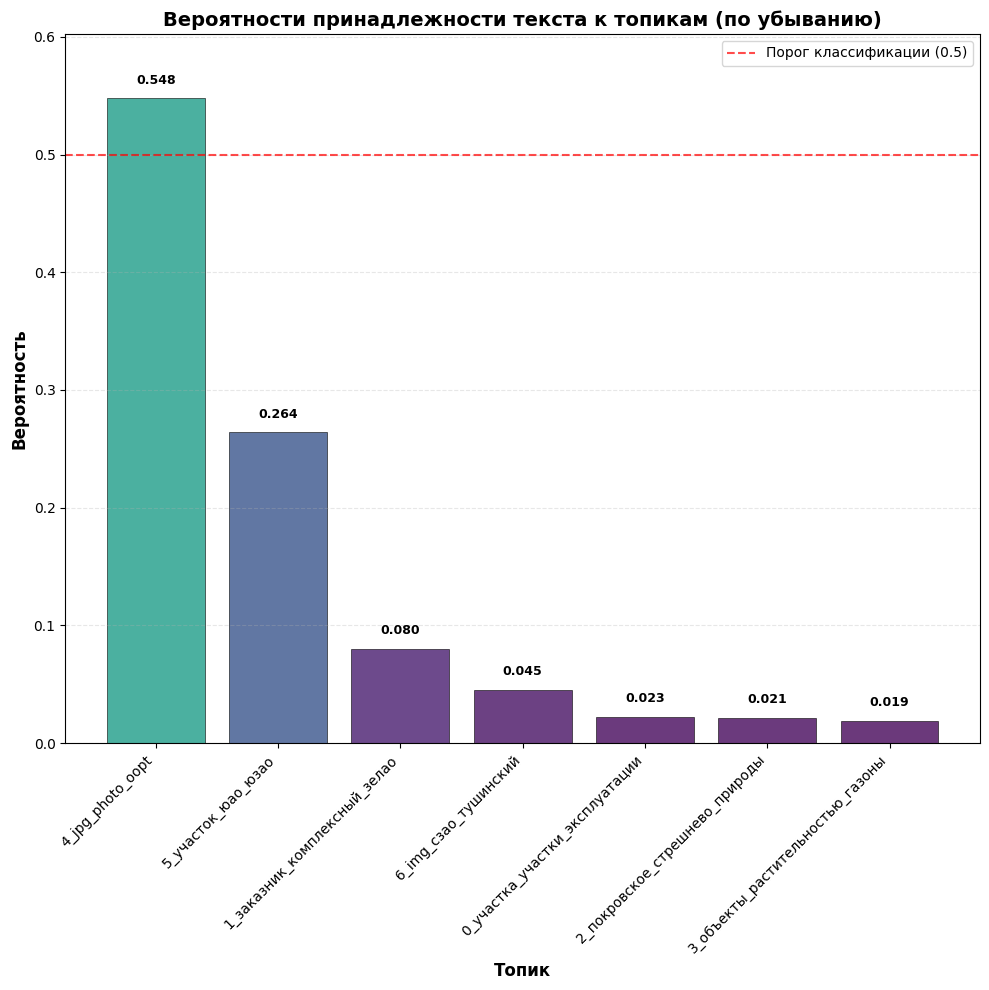

In [184]:
plt.figure(figsize=(10, 10))
bars = plt.bar(range(len(plt_df)), plt_df['probability'], 
               color=plt.cm.viridis(plt_df['probability']),
               alpha=0.8, edgecolor='black', linewidth=0.5)

# Настраиваем внешний вид
plt.xlabel('Топик', fontsize=12, fontweight='bold')
plt.ylabel('Вероятность', fontsize=12, fontweight='bold')

plt.title('Вероятности принадлежности текста к топикам (по убыванию)', fontsize=14, fontweight='bold')
plt.xticks(range(len(plt_df)), plt_df['topic_name'] , rotation=45, ha='right')
plt.ylim(0, min(1.1, max(plt_df['probability']) * 1.1))

# Добавляем линию порога классификации
threshold = 0.5
plt.axhline(y=threshold, color='red', linestyle='--', alpha=0.7, 
           label=f'Порог классификации ({threshold})')

# Добавляем значения вероятностей на столбцы
for i, (index, row) in enumerate(plt_df.iterrows()):
    plt.text(i, row['probability'] + 0.01, f'{row["probability"]:.3f}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

# Обновление модели на новых данных

In [185]:
lda_model.update(other_corpus)

D:\Artem\Projects\dam_system\.venv_LDA\Lib\site-packages\gensim\models\ldamodel.py:847: RuntimeWarning: divide by zero encountered in scalar divide
  perwordbound = self.bound(chunk, subsample_ratio=subsample_ratio) / (subsample_ratio * corpus_words)


In [186]:
# lda_model.get_topics()
lda_model.show_topic(0)

[('участка', 0.12001797),
 ('участки', 0.07512376),
 ('эксплуатации', 0.0030870081),
 ('действует', 0.0025169053),
 ('москвы', 0.0022170844),
 ('договор', 0.0015141846),
 ('города', 0.0014728658),
 ('земельного', 0.0014677872),
 ('аренды', 0.0013815808),
 ('государственное', 0.0013141084)]

In [187]:
# добавим колонки с вероятностями попадания объекта для каждого объекта в df
topic_columns_list = [f'topic_{i}' for i in range(lda_model.num_topics)]
for topic in topic_columns_list:
    final_df[topic] = 0.0
final_df

,text,tags,schema_name,table_name,cleaned_text,service_name,full_table_name,clean_split_text,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._47923,"[часть, территории, национального, парка, лоси...",0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710,"[часть, территории, национального, парка, лоси...",0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710,"[часть, территории, национального, парка, лоси...",0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710,"[часть, территории, национального, парка, лоси...",0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710,"[часть, территории, национального, парка, лоси...",0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo зелао комплексный заказник зеленогра...,440 Особо охраняемые природные территории,_46379._47876,"[jpg, photo, зелао, комплексный, заказник, зел...",0.0,0.0,0.0,0.0,0.0,0.0,0.0
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo юзао юао пип битцевский лес участок ...,440 Особо охраняемые природные территории,_46379._47876,"[jpg, photo, юзао, юао, пип, битцевский, лес, ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo юзао юао пип битцевский лес участок ...,440 Особо охраняемые природные территории,_46379._47876,"[jpg, photo, юзао, юао, пип, битцевский, лес, ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo зелао комплексный заказник зеленогра...,440 Особо охраняемые природные территории,_46379._47876,"[jpg, photo, зелао, комплексный, заказник, зел...",0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [188]:

def predict_topics_for_df(df):
    """Распределение вероятностей объектов датафрейма по топикам для"""
    copy_df = df.copy()
    for row_id, row in copy_df.iterrows():
        cleaned_text = row['cleaned_text']
        # print(cleaned_text)
        # cleaned_test_text_list = [clean_text(text_sample) for  text_sample in text_samples]
        # cleaned_test_texts_split_list = [cleaned_test_text.split() for cleaned_test_text in cleaned_test_text_list]
        cleaned_test_text_split_list = cleaned_text.split()
        document = id2word.doc2bow(cleaned_test_text_split_list)
        # print(document)
        # классифицируем первый текст
        vector = lda_model.get_document_topics(document)
        # print(vector)
        topic_dict = dict()
        for i in range(len(vector)):
            topic_name = 'topic_' + str(vector[i][0])
            topic_prob = vector[i][1]
            topic_dict[topic_name] = topic_prob
        # print(topic_dict)
        for topic, prob in topic_dict.items():
            copy_df.loc[row_id, topic] = prob
    
    return copy_df
            
res_df = predict_topics_for_df(final_df)
res_df
    
#     print(vector)
# 
# vector = sorted(vector, key=lambda x: x[1], reverse=True)
# vector

,text,tags,schema_name,table_name,cleaned_text,service_name,full_table_name,clean_split_text,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._47923,"[часть, территории, национального, парка, лоси...",0.775268,0.00000,0.054634,0.000000,0.090528,0.068246,0.0
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710,"[часть, территории, национального, парка, лоси...",0.439509,0.00000,0.030726,0.502960,0.020043,0.000000,0.0
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710,"[часть, территории, национального, парка, лоси...",0.217781,0.00000,0.012035,0.760055,0.000000,0.000000,0.0
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710,"[часть, территории, национального, парка, лоси...",0.146157,0.00000,0.018051,0.821624,0.010594,0.000000,0.0
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,440 Особо охраняемые природные территории,_46379._58710,"[часть, территории, национального, парка, лоси...",0.204461,0.00000,0.000000,0.780094,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo зелао комплексный заказник зеленогра...,440 Особо охраняемые природные территории,_46379._47876,"[jpg, photo, зелао, комплексный, заказник, зел...",0.000000,0.48834,0.000000,0.000000,0.474708,0.026197,0.0
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo юзао юао пип битцевский лес участок ...,440 Особо охраняемые природные территории,_46379._47876,"[jpg, photo, юзао, юао, пип, битцевский, лес, ...",0.000000,0.00000,0.000000,0.000000,0.457457,0.528158,0.0
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo юзао юао пип битцевский лес участок ...,440 Особо охраняемые природные территории,_46379._47876,"[jpg, photo, юзао, юао, пип, битцевский, лес, ...",0.000000,0.00000,0.000000,0.000000,0.457457,0.528158,0.0
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photo зелао комплексный заказник зеленогра...,440 Особо охраняемые природные территории,_46379._47876,"[jpg, photo, зелао, комплексный, заказник, зел...",0.000000,0.48834,0.000000,0.000000,0.474708,0.026197,0.0


In [189]:
def tables_in_topic(df, topic_id, threshold = 0.5):
    """определяет какие таблицы находятся в топике"""
    copy_df = df.copy()
    topic_name = 'topic_' + str(topic_id)
    copy_df = copy_df[copy_df[topic_name] >= threshold]
    unique_tables = copy_df['full_table_name'].unique().tolist()
    result_dict = defaultdict(dict)
    for table in unique_tables:
        result_dict[table]['in_topic'] = len(copy_df[copy_df['full_table_name'] == table])
        result_dict[table]['total'] = len(df[df['full_table_name'] == table])
        result_dict[table]['ratio'] = round(result_dict[table]['in_topic'] / result_dict[table]['total'], 2)
    return result_dict

result_dict = tables_in_topic(res_df, 0)
result_dict
    

defaultdict(dict,
            {'_46379._47923': {'in_topic': 1, 'total': 1, 'ratio': 1.0},
             '_46379._47925': {'in_topic': 1, 'total': 1, 'ratio': 1.0},
             '_46379._47928': {'in_topic': 64, 'total': 64, 'ratio': 1.0},
             '_46379._54936': {'in_topic': 37, 'total': 2485, 'ratio': 0.01},
             '_46379._51704': {'in_topic': 1, 'total': 164, 'ratio': 0.01},
             '_46379._51701': {'in_topic': 2, 'total': 108, 'ratio': 0.02},
             '_46379._51700': {'in_topic': 5, 'total': 146, 'ratio': 0.03},
             '_46379._51702': {'in_topic': 4, 'total': 133, 'ratio': 0.03},
             '_46379._51703': {'in_topic': 2583, 'total': 2992, 'ratio': 0.86},
             '_46379._51706': {'in_topic': 2, 'total': 156, 'ratio': 0.01},
             '_46379._46398': {'in_topic': 10, 'total': 342, 'ratio': 0.03}})

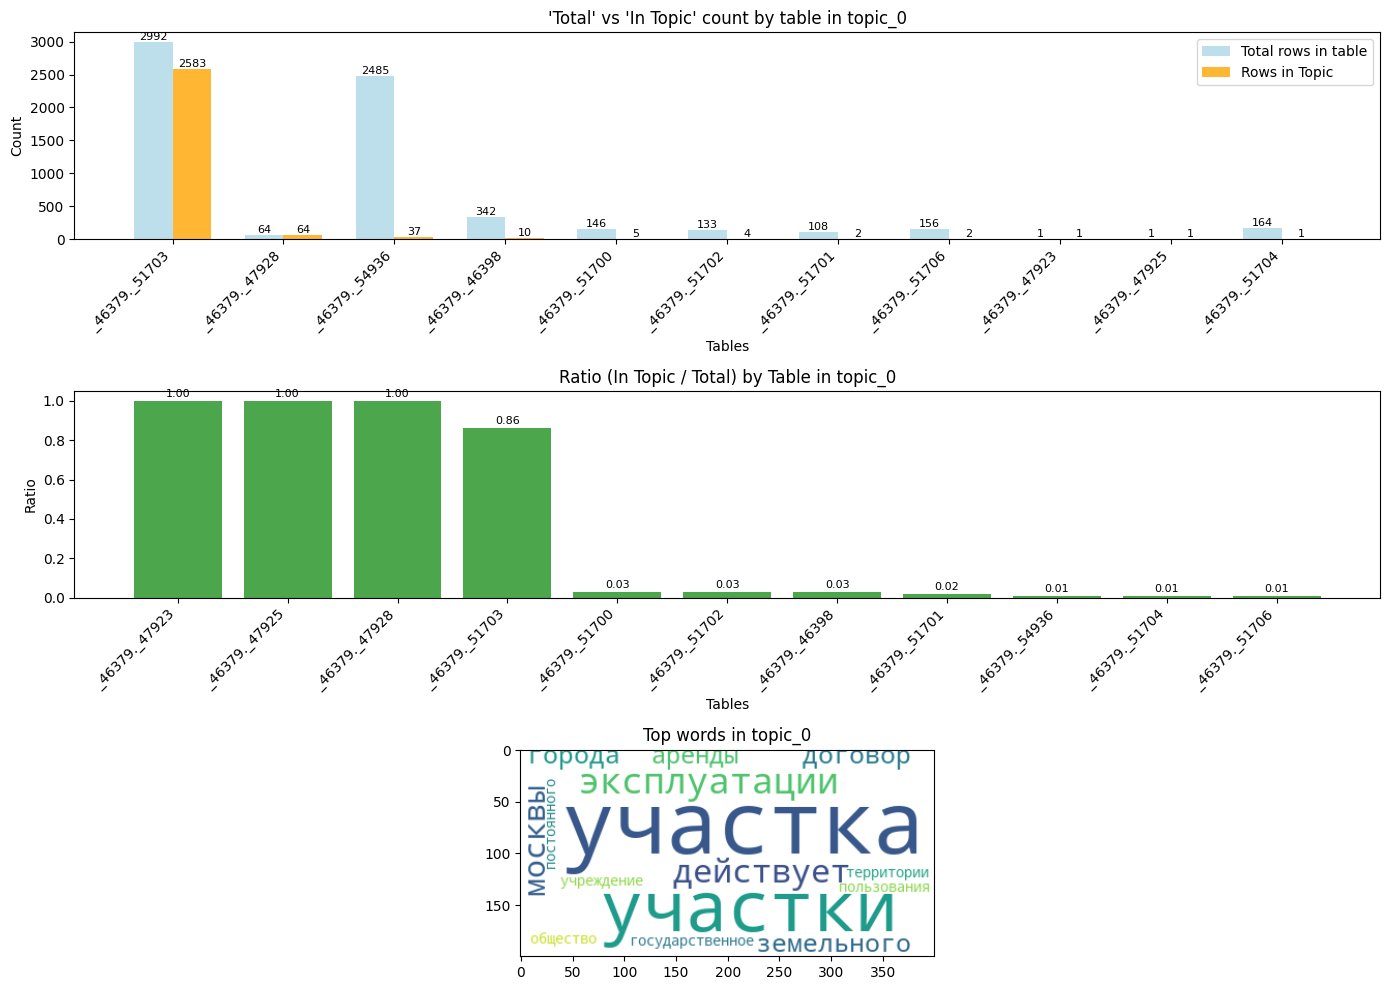

In [190]:
def plot_topic_tables(df, topic_id = 0, threshold = 0.5):
    """отображение находящихся в топике таблиц и топ слов"""
    topic_name = 'topic_' + str(topic_id)
    df_copy = df.copy()
    result_dict = tables_in_topic(df=df_copy, topic_id=topic_id, threshold=threshold)
    
    # Создаём и сортируем словарь по in_topic в порядке убывания
    sorted_items_by_topic = sorted(result_dict.items(), key=lambda x: x[1]['in_topic'], reverse=True)
    # Создаём и сортируем словарь по ratio в порядке убывания
    sorted_items_by_ratio = sorted(result_dict.items(), key=lambda x: x[1]['ratio'], reverse=True)
    
    
    # Извлекаем данные для графика
    # отсортированные данные для первого графика
    tables_for_topic = [item[0] for item in sorted_items_by_topic]
    in_topic_for_topic= [item[1]['in_topic'] for item in sorted_items_by_topic]
    total_for_topic = [item[1]['total'] for item in sorted_items_by_topic]
    # отсортированные данные для второго графика
    tables_for_ratio = [item[0] for item in sorted_items_by_ratio]
    ratios = [item[1]['ratio'] for item in sorted_items_by_ratio]
    
    # Создаем фигуру и оси
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))
    
    # Первый график - столбчатая диаграмма с двумя барами
    x = np.arange(len(tables_for_topic))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, total_for_topic, width, label='Total rows in table', alpha=0.8, color='lightblue')
    bars2 = ax1.bar(x + width/2, in_topic_for_topic, width, label='Rows in Topic', alpha=0.8, color='orange')
    
    ax1.set_xlabel('Tables')
    ax1.set_ylabel('Count')
    ax1.set_title(f"'Total' vs 'In Topic' count by table in {topic_name}")
    ax1.set_xticks(x)
    ax1.set_xticklabels(tables_for_topic, rotation=45, ha='right')
    ax1.legend()
    
    # Добавляем значения на столбцы
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        ax1.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height() + 0.5, 
                str(total_for_topic[i]), ha='center', va='bottom', fontsize=8)
        ax1.text(bar2.get_x() + bar2.get_width()/2, bar2.get_height() + 0.5, 
                str(in_topic_for_topic[i]), ha='center', va='bottom', fontsize=8)
    
    
    # Второй график - ratio
    
    
    bars3 = ax2.bar(x, ratios, color='green', alpha=0.7)
    ax2.set_xlabel('Tables')
    ax2.set_ylabel('Ratio')
    ax2.set_title(f'Ratio (In Topic / Total) by Table in {topic_name}')
    ax2.set_xticks(x)
    ax2.set_xticklabels(tables_for_ratio, rotation=45, ha='right')
    
    # Добавляем значения ratio на столбцы
    for i, bar in enumerate(bars3):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{ratios[i]:.2f}', ha='center', va='bottom', fontsize=8)
    
    keywords_stats = dict(lda_model.show_topic(topic_id, topn=15)) 
    wordcloud = WordCloud(width=400, height=200, background_color='white').generate_from_frequencies(
           keywords_stats)
    ax3.imshow(wordcloud, interpolation='bilinear')
    ax3.set_title(f"Top words in {topic_name}")
    
    plt.tight_layout()
    plt.show()

# Использование
plot_topic_tables(df=res_df, topic_id=0, threshold=0.5)

In [191]:
keywords_stats = dict(lda_model.show_topic(0))
keywords_stats

{'участка': 0.12001797,
 'участки': 0.07512376,
 'эксплуатации': 0.0030870081,
 'действует': 0.0025169053,
 'москвы': 0.0022170844,
 'договор': 0.0015141846,
 'города': 0.0014728658,
 'земельного': 0.0014677872,
 'аренды': 0.0013815808,
 'государственное': 0.0013141084}

# Создать два графа с pyvis. Но для этого сначала стандартихировать эти графы с учётом входной информации, тегов, именованных сущностей, связей, метаинфы и т.д.: </br>
## 1. с кластерами
## 2. только с таблицами
